### Mashiur Rahman

# Project 5 — Discover Topics in Text

## Part 1 — Load and Explore the Data

### Import the required Librarry

In [20]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

### Load the Data

In [7]:
news = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes"),
    random_state=42
)

documents = news.data

print("Number of documents:", len(documents))
print("Number of categories:", len(news.target_names))

Number of documents: 18846
Number of categories: 20


### Category Names

In [2]:
for name in news.target_names:
    print(name)

alt.atheism
comp.graphics
comp.os.ms-windows.misc
comp.sys.ibm.pc.hardware
comp.sys.mac.hardware
comp.windows.x
misc.forsale
rec.autos
rec.motorcycles
rec.sport.baseball
rec.sport.hockey
sci.crypt
sci.electronics
sci.med
sci.space
soc.religion.christian
talk.politics.guns
talk.politics.mideast
talk.politics.misc
talk.religion.misc


### Example Documents

In [3]:
for i in range(3):
    print("DOCUMENT", i + 1)
    print(documents[i][:700])
    print("-" * 50)

DOCUMENT 1


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PE
--------------------------------------------------
DOCUMENT 2
My brother is in the market for a high-performance video card that supports
VESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:

  - Diamond Stealth Pro Local Bus

  - Orchid Farenheit 1280

  - ATI Graphics

### Part 1 Answer

**Why can't we simply give the original text to K-Means?**

K-Means works with numerical features so it can calculate distances between documents. The original posts are strings of words, not numerical vectors. 

## Part 2 — Convert Text into Numbers

In [8]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=2000
)

X_tfidf = vectorizer.fit_transform(documents)

In [9]:
print("Number of documents:", X_tfidf.shape[0])
print("Number of features:", X_tfidf.shape[1])
print("A few feature names:")
print(vectorizer.get_feature_names_out()[:20])

Number of documents: 18846
Number of features: 2000
A few feature names:
['00' '000' '01' '02' '03' '04' '05' '06' '0d' '0t' '10' '100' '1000' '11'
 '12' '128' '13' '130' '14' '145']


## Part 3 — Group the Documents

I used K-Means with K = 5 to group the documents by their TF-IDF features.

#### Create the clusters

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_tfidf)

#### Examine the assignments and counts

In [13]:
print("First 20 cluster assignments:")
print(cluster_labels[:20])

cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
cluster_counts.index.name = "Cluster"
cluster_counts.name = "Number of documents"

print("\nDocuments in each cluster:")
display(cluster_counts)

print("Total documents:", cluster_counts.sum())

First 20 cluster assignments:
[1 2 3 2 2 0 0 1 3 0 0 0 3 0 0 0 2 0 3 3]

Documents in each cluster:


Cluster
0    8588
1     988
2    3575
3    4933
4     762
Name: Number of documents, dtype: int64

Total documents: 18846


### Part 3 Observation

K-Means assigned each document to one of five clusters, numbered 0 to 4. The table shows how many documents are in each cluster. These numbers are only group identifiers; I will examine the words and documents in Part 4 to understand what each group is about.

## Part 4 — Understand the Clusters

#### show words and documents

In [14]:
feature_names = vectorizer.get_feature_names_out()

for cluster in range(5):
    top_word_numbers = kmeans.cluster_centers_[cluster].argsort()[-8:][::-1]
    top_words = feature_names[top_word_numbers]

    print("\nCLUSTER", cluster)
    print("Top words:", ", ".join(top_words))

    document_numbers = [i for i, label in enumerate(cluster_labels) if label == cluster]

    for number in document_numbers[:2]:
        excerpt = documents[number].replace("\n", " ").strip()
        print("Document:", excerpt[:400])


CLUSTER 0
Top words: edu, new, like, com, good, just, used, use
Document: Back in high school I worked as a lab assistant for a bunch of experimental psychologists at Bell Labs.  When they were doing visual perception and memory experiments, they used vector-type displays, with 1-millisecond refresh rates common.  So your case of 1/200th sec is quite practical, and the experimenters were probably sure that it was 5 milliseconds, not 4 or 6 either.   Steve
Document: AE is in Dallas...try 214/241-6060 or 214/241-0055.  Tech support may be on their own line, but one of these should get you started.

CLUSTER 1
Top words: game, team, games, year, hockey, players, season, baseball
Document: I am sure some bashers of Pens fans are pretty confused about the lack of any kind of posts about the recent Pens massacre of the Devils. Actually, I am  bit puzzled too and a bit relieved. However, I am going to put an end to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they are kil

### Possible topics

### Part 4 — Answers

| Cluster | Common words | Possible topic |
|---|---|---|
| 0 | edu, new, like, com, good | Mixed or unclear |
| 1 | game, team, hockey, players, baseball | Sports |
| 2 | windows, drive, card, file | Computers and hardware |
| 3 | people, think, government | Mixed discussions or opinions |
| 4 | god, jesus, christ, bible, faith | Religion and Christianity |

**Do the documents within each cluster appear to discuss similar topics?**

Some do. Both example documents in Cluster 1 discuss sports, both in Cluster 2 discuss computer hardware, and both in Cluster 4 discuss religion. Clusters 0 and 3 are harder to interpret: their common words are broad, and the example documents discuss different subjects. Therefore, the five clusters do not all represent one clear topic each.

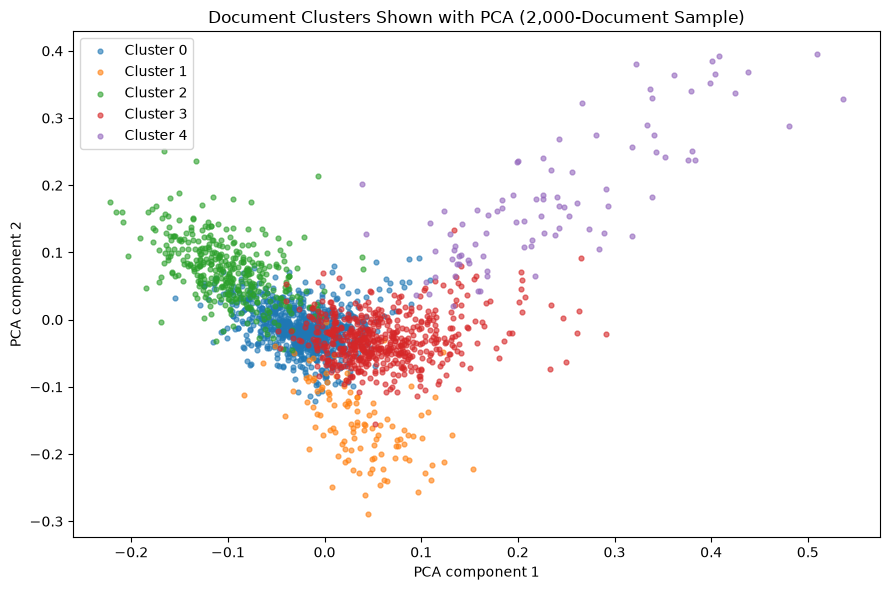

In [21]:

# Choose the same random sample each time
rng = np.random.default_rng(42)
sample_numbers = rng.choice(X_tfidf.shape[0], size=2000, replace=False)

# PCA needs the sampled data as a regular array
sample_data = X_tfidf[sample_numbers].toarray()
sample_clusters = cluster_labels[sample_numbers]

pca = PCA(n_components=2, svd_solver="randomized", random_state=42)
points = pca.fit_transform(sample_data)

plt.figure(figsize=(9, 6))

for cluster in range(5):
    selected = sample_clusters == cluster
    plt.scatter(
        points[selected, 0],
        points[selected, 1],
        s=12,
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

plt.title("Document Clusters Shown with PCA (2,000-Document Sample)")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend()
plt.tight_layout()
plt.show()

### Part 5 — Answers

**Are some clusters clearly separated?**  
Some clusters form noticeable groups. Cluster 2 (green) is mainly toward the upper left, Cluster 1 (orange) extends downward, and Cluster 4 (purple) extends toward the upper right. However, none is completely separate.

**Are some clusters overlapping?**  
Yes. Several colours overlap near the centre of the plot, especially Clusters 0 (blue) and 3 (red).

**What does this tell you about grouping text documents?**  
K-Means found some differences between the documents, but the topics are not perfectly distinct. Documents can share words or discuss more than one subject. Also, this PCA plot shows only two dimensions of the TF-IDF data, so it does not show every difference between documents.

## Final Analysis

1. **What is TF-IDF and why is it useful for text data?**  
   TF-IDF converts documents into numbers. It gives more weight to words that help distinguish one document from others and less weight to words that appear in many documents. This allowed me to use K-Means on the news posts.

2. **What value of K did you use?**  
   I used **K = 5**, so K-Means divided the documents into five clusters.

3. **What topics did you find in the clusters?**  
   Cluster 1 mainly discussed sports, Cluster 2 discussed computers and hardware, and Cluster 4 discussed Christian beliefs and religious questions. Clusters 0 and 3 contained mixed discussions, so I could not give them one clear topic.

4. **Did the documents within each cluster appear similar?**  
   Some did. The example documents in Clusters 1, 2, and 4 discussed similar subjects. The examples in Clusters 0 and 3 were less similar.

5. **Were some clusters difficult to interpret?**  
   Yes. Clusters 0 and 3 were difficult to interpret because their top words were broad and their example documents discussed different subjects.

6. **What did the PCA visualization show?**  
   In the 2,000-document sample, some clusters formed noticeable groups, but they also overlapped. For example, Clusters 0 and 3 overlapped near the centre of the plot. The groups were not completely separated.

7. **What is one limitation of using K-Means for text?**  
   K-Means assigns every document to one cluster, even when a document discusses several topics. As a result, some clusters can contain mixed subjects and be difficult to interpret.